# Residue Class Compression

For each residue class mod 2^k, the first k Collatz steps are deterministic. We compress these into a single map and study which classes shrink vs grow.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from collatz.residue import compressed_map, shrink_fraction

## Shrink fraction vs k

Key question: as k grows, does the fraction of residue classes that shrink approach 1?

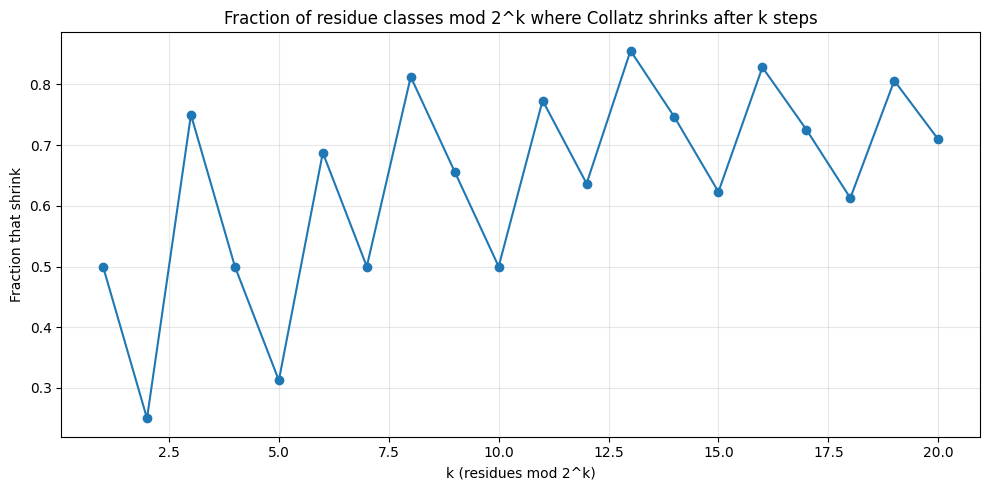

k= 1: 0.500000 (       1 /        2)
k= 2: 0.250000 (       1 /        4)
k= 3: 0.750000 (       6 /        8)
k= 4: 0.500000 (       8 /       16)
k= 5: 0.312500 (      10 /       32)
k= 6: 0.687500 (      44 /       64)
k= 7: 0.500000 (      64 /      128)
k= 8: 0.812500 (     208 /      256)
k= 9: 0.656250 (     336 /      512)
k=10: 0.500000 (     512 /     1024)
k=11: 0.773438 (    1584 /     2048)
k=12: 0.636719 (    2608 /     4096)
k=13: 0.855469 (    7008 /     8192)
k=14: 0.746094 (   12224 /    16384)
k=15: 0.623047 (   20416 /    32768)
k=16: 0.828125 (   54272 /    65536)
k=17: 0.725586 (   95104 /   131072)
k=18: 0.612793 (  160640 /   262144)
k=19: 0.806152 (  422656 /   524288)
k=20: 0.709473 (  743936 /  1048576)


In [2]:
ks = list(range(1, 21))
fracs = [shrink_fraction(k) for k in ks]

plt.figure(figsize=(10, 5))
plt.plot(ks, fracs, "o-")
plt.xlabel("k (residues mod 2^k)")
plt.ylabel("Fraction that shrink")
plt.title("Fraction of residue classes mod 2^k where Collatz shrinks after k steps")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for k, f in zip(ks, fracs, strict=True):
    print(f"k={k:2d}: {f:.6f} ({int(f * 2**k):>8d} / {2**k:>8d})")

## Growth factor distribution

For each residue class, the growth factor is multiplier / 2^divisions. Let's see the distribution.

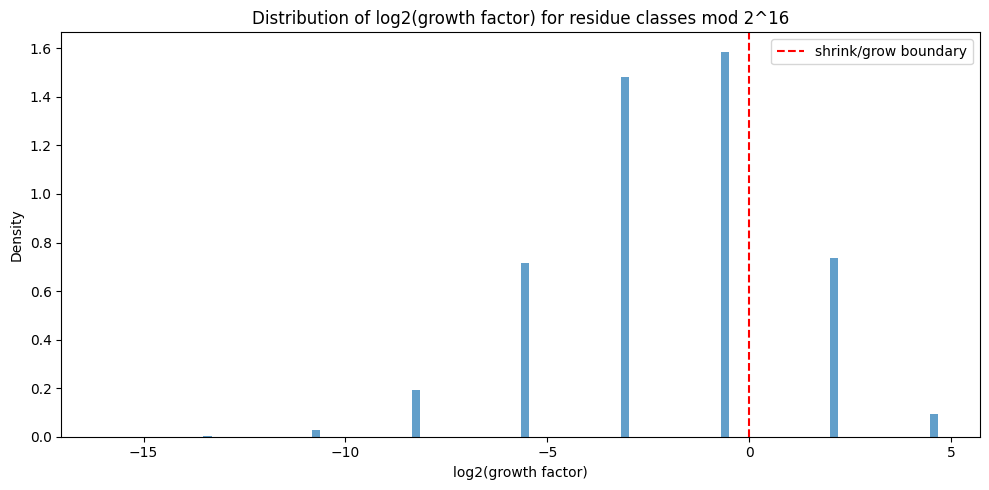

Mean log2(factor): -1.926320
Fraction < 0 (shrinking): 0.828125


In [3]:
from math import log2

k = 16
cmap = compressed_map(k)
log_factors = [log2(entry["multiplier"]) - entry["divisions"] for entry in cmap]

plt.figure(figsize=(10, 5))
plt.hist(log_factors, bins=100, density=True, alpha=0.7)
plt.axvline(x=0, color="r", linestyle="--", label="shrink/grow boundary")
plt.xlabel("log2(growth factor)")
plt.ylabel("Density")
plt.title(f"Distribution of log2(growth factor) for residue classes mod 2^{k}")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean log2(factor): {np.mean(log_factors):.6f}")
print(f"Fraction < 0 (shrinking): {np.mean(np.array(log_factors) < 0):.6f}")

## Structure of non-shrinking classes

Which residue classes fail to shrink? Is there a pattern?

In [4]:
k = 12
cmap = compressed_map(k)
non_shrinking = [entry for entry in cmap if not entry["shrinks"]]

print(f"Non-shrinking classes mod 2^{k}: {len(non_shrinking)} / {2**k}")
print("\nFirst 20 non-shrinking residues:")
for entry in non_shrinking[:20]:
    r = entry["residue"]
    factor = log2(entry["multiplier"]) - entry["divisions"]
    print(f"  r={r:4d} (binary: {r:012b}), log2(factor)={factor:+.4f}")

Non-shrinking classes mod 2^12: 1488 / 4096

First 20 non-shrinking residues:
  r=   7 (binary: 000000000111), log2(factor)=+0.9248
  r=   9 (binary: 000000001001), log2(factor)=+0.9248
  r=  18 (binary: 000000010010), log2(factor)=+0.9248
  r=  19 (binary: 000000010011), log2(factor)=+0.9248
  r=  25 (binary: 000000011001), log2(factor)=+0.9248
  r=  27 (binary: 000000011011), log2(factor)=+3.5098
  r=  31 (binary: 000000011111), log2(factor)=+3.5098
  r=  39 (binary: 000000100111), log2(factor)=+0.9248
  r=  41 (binary: 000000101001), log2(factor)=+3.5098
  r=  47 (binary: 000000101111), log2(factor)=+0.9248
  r=  54 (binary: 000000110110), log2(factor)=+0.9248
  r=  55 (binary: 000000110111), log2(factor)=+0.9248
  r=  57 (binary: 000000111001), log2(factor)=+0.9248
  r=  62 (binary: 000000111110), log2(factor)=+0.9248
  r=  63 (binary: 000000111111), log2(factor)=+3.5098
  r=  71 (binary: 000001000111), log2(factor)=+0.9248
  r=  73 (binary: 000001001001), log2(factor)=+0.9248
  r=